# 📘 Notebook – Etapa Descritiva (base para Análise Preditiva)

## Análise Exploratória e Qualidade dos Dados (EDA)

Esta seção descreve a estrutura e a qualidade do conjunto de dados utilizados no estudo.  
**Fonte:** [ Lesões no Futebol Europeu 2020–2025 (Kaggle) ]( https://www.kaggle.com/datasets/sananmuzaffarov/european-football-injuries-2020-2025 )  
 **Licença:** CC BY-SA 4.0 — https://creativecommons.org/licenses/by-sa/4.0/

---

### 1) Importações e carregamento do conjunto de dados

In [34]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

## 2) Visão geral

### Coleta de Dados do Kaggle

In [35]:
# Acessando dataset European Football Injuries (2020-2025)
sys.path.append(os.path.abspath(os.path.join('..', '..')))

In [36]:
from src.data_loader import load_injuries_data

df_injuries = load_injuries_data()

In [37]:

print ("Linhas:", df_injuries.shape[0])
print ("Colunas:", df_injuries.shape[1])
print ("\nNome das colunas:", list(df_injuries.columns))

Linhas: 15603
Colunas: 11

Nome das colunas: ['Season', 'Injury', 'Days', 'Games missed', 'injury_from_parsed', 'injury_until_parsed', 'player_name', 'player_age', 'player_position', 'club', 'league']


In [38]:
print(df_injuries.dtypes)

Season                   str
Injury                   str
Days                     str
Games missed           int64
injury_from_parsed       str
injury_until_parsed      str
player_name              str
player_age             int64
player_position          str
club                     str
league                   str
dtype: object


In [39]:
df_injuries.head()

,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
0,20/21,Syndesmosis ligament tear,43 days,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37 days,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21 days,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
3,20/21,bruise,8 days,2,11/6/2020,11/13/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
4,20/21,Ligament injury,22 days,2,7/26/2020,8/16/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga


In [40]:
df_injuries.tail()

,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
15598,24/25,Calf muscle tear,22 days,2,3/14/2025,4/4/2025,Taty Castellanos,27,Forward,Lazio,Serie A
15599,24/25,Adductor injury,25 days,6,2/15/2025,3/11/2025,Taty Castellanos,27,Forward,Lazio,Serie A
15600,24/25,Adductor injury,9 days,2,9/16/2024,9/24/2024,Taty Castellanos,27,Forward,Lazio,Serie A
15601,24/25,Ankle injury,6 days,1,2/9/2025,2/14/2025,Boulaye Dia,28,Forward,Lazio,Serie A
15602,24/25,Ankle injury,10 days,3,11/28/2024,12/7/2024,Boulaye Dia,28,Forward,Lazio,Serie A


O dataset contém registros de eventos de lesão/indisponibilidade de jogadores profissionais
de futebol nas cinco principais ligas europeias: **Bundesliga, Premier League, La Liga,
Ligue 1 e Série A**. Cada linha representa um evento único de afastamento associado a um
jogador, com informações de contexto (clube e liga), características do atleta (idade e
posição) e impacto esportivo (dias afastados e jogos perdidos).
  - **
Total de registros:** 15.603 - **   
Total de atributos: ** 11 - ** Temporados presentes   
: ** 20/21 , 21/22 , 22/23 , 23/24 , 24/25

In [41]:
dicionario = pd.DataFrame({
    "Atributo": [
        "Season" , "Injury" , "Days" , "Games Missed" , "injury_from_parsed" ,
        "injury_until_parsed" , "player_name" , "player_age" , "player_position" ,
        "club" , "league"
    ],
    "Descricao": [
        "Temporada da ocorrência" ,
         "Tipo/descrição da lesão ou condição" ,
         "Duração do afastamento (texto, ex: '43 dias')" ,
         "Número de partidas perdidas" ,
         "Data de início do afastamento" ,
         "Data de fim do afastamento" ,
         "Nome do jogador" ,
         "Idade do jogador no evento" ,
         "Posição tática do jogador" ,
         "Clube do jogador" ,
         "Liga associada ao clube"
    ],
    "Tipo (arquivo)": [
        "texto" , "texto" , "texto" , "inteiro" , "texto (dados)" ,
        "texto (dados)" , "texto" , "inteiro" , "texto" , "texto" ,
        "texto"
    ],
    "Unidade/Formato": [
        "—" , "—" , "dias" , "jogos" , "M/D/YYYY" , "M/D/YYYY" ,
        "—" , "anos" , "—" , "—" , "—"
    ],
    "Exemplos": [
        "20/21, 24/25",
        "Lesão no tendão da coxa, lesão no joelho",
        "43 dias, 8 dias" ,
         "9, 2, 145" ,
         "28/01/2021" ,
         "11/03/2021" ,
         "Benjamin Pavard" ,
         "19, 25, 43" ,
         "Goleiro, Zagueiro Central" ,
         "Bayern de Munique" ,
          "Bundesliga, Seria A"
    ]
})

print(dicionario.to_string(index=False))

           Atributo                                     Descricao Tipo (arquivo) Unidade/Formato                                 Exemplos
             Season                       Temporada da ocorrência          texto               —                             20/21, 24/25
             Injury           Tipo/descrição da lesão ou condição          texto               — Lesão no tendão da coxa, lesão no joelho
               Days Duração do afastamento (texto, ex: '43 dias')          texto            dias                          43 dias, 8 dias
       Games Missed                   Número de partidas perdidas        inteiro           jogos                                9, 2, 145
 injury_from_parsed                 Data de início do afastamento  texto (dados)        M/D/YYYY                               28/01/2021
injury_until_parsed                    Data de fim do afastamento  texto (dados)        M/D/YYYY                               11/03/2021
        player_name               

In [42]:
df_injuries = df_injuries.rename(columns={
    "Season": "temporada",
    "Injury": "tipo_lesao",
    "Days": "duracao_dias",
    "Games missed": "jogos_perdidos",
    "injury_from_parsed": "data_inicio_lesao",
    "injury_until_parsed": "data_fim_lesao",
    "player_name": "jogador",
    "player_age": "idade",
    "player_position": "posicao",
    "club": "clube",
    "league": "liga",

})

Para uma anális mais didática, realizamos a tradução das colunas do dataset para pt_BR

In [43]:
# Lista quantidade de linhas e coculas

print(f'''
    Colunas: {len(df_injuries.columns)} - {df_injuries.columns.values}
  ''')


    Colunas: 11 - <StringArray>
[        'temporada',        'tipo_lesao',      'duracao_dias',
    'jogos_perdidos', 'data_inicio_lesao',    'data_fim_lesao',
           'jogador',             'idade',           'posicao',
             'clube',              'liga']
Length: 11, dtype: str
  


## 3) Dados ausentes

In [44]:
missing = df_injuries.isna().sum()
print("\nMissing por coluna:")
print(missing)


Missing por coluna:
temporada            0
tipo_lesao           0
duracao_dias         0
jogos_perdidos       0
data_inicio_lesao    0
data_fim_lesao       0
jogador              0
idade                0
posicao              0
clube                0
liga                 0
dtype: int64


Não foram encontrados valores ausentes em nenhuma das 11 colunas do conjunto de dados
(** 0 % de dados faltantes**). O conjunto de dados está completamente preenchido, o que
elimina a necessidade de imputação ou remoção de registros nesta etapa.

## 4) Duplicatas


In [45]:
dup_count = df_injuries.duplicated().sum()
print("\nDuplicatas exatas (linhas idênticas):", dup_count)


Duplicatas exatas (linhas idênticas): 0


Não foram identificadas duplicatas exatas de linha (** 0 registros duplicados**).
Cada observação representa um evento de afastamento distinto, garantindo a
integridade dos registros para análises longitudinais.

### 5) Consistência temporal e coerência entre variáveis

In [46]:
# Converter dias para numérico
days_num = df_injuries['duracao_dias'].astype(str).str.extract(r"(\d+)")[0].astype(int)
print("\nDura das lesões (dias) - min/max:", np.nanmin(days_num), "e", np.nanmax(days_num))

# Datas
from_dt = pd.to_datetime(df_injuries['data_inicio_lesao'], errors="coerce")
until_dt = pd.to_datetime(df_injuries['data_fim_lesao'], errors="coerce")

print("\nFalhas de parsing - data_inicio_lesao:", from_dt.isna().sum())
print("\nFalhas de parsing - data_fim_lesao:", until_dt.isna().sum())

print("\nPeríodo (datas):")
print("Min data_inicio_lesao:", from_dt.min())
print("Max data_fim_lesao:", until_dt.max())

# Inconsistência: fim antes do início
until_before_from = ((~from_dt.isna()) & (~until_dt.isna()) & (until_dt < from_dt)).sum()
print("\nCasos com until < from:", until_before_from)

# Coerência: Days vs (until - from)
duration_from_dates = (until_dt - from_dt).dt.days
mask_valid = (~days_num.isna()) & (~duration_from_dates.isna())
diff = (days_num[mask_valid] - duration_from_dates[mask_valid]).abs()

mismatch_gt3 = (diff > 3).sum()
print("\nDivergências | dias - (until-from)| > 3 dias:", mismatch_gt3)

# removendo casos de Covid
df_injuries = df_injuries[~df_injuries['tipo_lesao'].str.contains(r'Corona virus|Quarantine', case=False, na=False)]
print("\nRegistros com 'Corona virus' removidos. Total agora:", len(df_injuries))


Dura das lesões (dias) - min/max: 1 e 1013

Falhas de parsing - data_inicio_lesao: 0

Falhas de parsing - data_fim_lesao: 0

Período (datas):
Min data_inicio_lesao: 2020-02-01 00:00:00
Max data_fim_lesao: 2026-01-15 00:00:00

Casos com until < from: 0

Divergências | dias - (until-from)| > 3 dias: 0

Registros com 'Corona virus' removidos. Total agora: 14489


A análise de consistência temporal revelou:

- **Análise de dados:** sem falhas de conversão em ambas as colunas de dados.
- **Período coberto:** de ** 2020 -02-01** a ** 2026 -01- 15 ** *(o limite superior ultrapassa
   2025 em função de dados de retorno registrados no arquivo)*.
- **Ordem temporal:** nenhum caso com dados de fim anterior à data de   início
  (** sem exceções**).
- **Coerência `Dias` vs intervalo entre dados:** nenhuma divergência absoluta superior
  a 3 dias (** sem ocorrências**), diminuição boa consistência interna entre a duração
  declarada e como dados registrados.

## 6) Convertendo dados da tabela

In [47]:
# Converter dias para numérico
df_injuries['duracao_dias'] = df_injuries['duracao_dias'].astype(str).str.extract(r"(\d+)")[0].astype(int)
print("\nDura das lesões (dias) - min/max:", np.nanmin(days_num), "e", np.nanmax(days_num))

# Datas
df_injuries['data_inicio_lesao'] = pd.to_datetime(df_injuries['data_inicio_lesao'], errors="coerce")
df_injuries['data_fim_lesao'] = pd.to_datetime(df_injuries['data_fim_lesao'], errors="coerce")

print(df_injuries.dtypes)


Dura das lesões (dias) - min/max: 1 e 1013
temporada                       str
tipo_lesao                      str
duracao_dias                  int64
jogos_perdidos                int64
data_inicio_lesao    datetime64[us]
data_fim_lesao       datetime64[us]
jogador                         str
idade                         int64
posicao                         str
clube                           str
liga                            str
dtype: object


## 7) Outliers via IQR

In [48]:
def iqr_outliers(serie):
  s = pd.to_numeric(serie, errors="coerce").dropna()
  q1 = s.quantile(.25)
  q3 = s.quantile(.75)
  iqr = q3 - q1
  low = q1 - 1.5 * iqr
  high = q3 + 1.5 * iqr
  out_count = ((s < low) | (s > high)).sum()
  return int(out_count), float(low), float(high)


out_games_cnt, out_games_low, out_games_high = iqr_outliers(df_injuries['jogos_perdidos'])
out_days_cnt, out_days_low, out_days_high = iqr_outliers(df_injuries['duracao_dias'])
print("\nOutliers (IQR) - Jogos perdidos:", out_games_cnt, "| limites", (out_games_low, out_games_high))
print("\nOutliers (IQR) - Dias (num):", out_days_cnt, "| limites", (out_days_low, out_days_high))


Outliers (IQR) - Jogos perdidos: 1002 | limites (-8.0, 16.0)

Outliers (IQR) - Dias (num): 1320 | limites (-40.5, 91.5)


Para identificar valores extremos utilizados-se o seletivos do **IQR (1,5×IQR)**. Os
outliers foram **contabilizados, mas não removidos**, pois podem representar casos
reais de lesões graves (ex.: ruptura do ligamento cruzado anterior) e são relevantes para análises de severidade.

| Variável | Faixa observada | Limite superior IQR | Outliers identificados |
|---|---|---|---|
| `Jogos perdidos` | 1 a 145 jogos | ~13,5 jogos | **1.367 registros** |
| `Dias` (numérico) | 1 a 1.013 dias | ~84 dias | **1.497 registros** |

**Implicação analítica:** devido à presença de caudas mais longas, recomenda-se:
- Utilização **mediana e percentis** em estatísticas descritivas.
- Avaliar **winsorização** ou **segmentação por tipo de lesão/posição** em modelos
  preditivos, conforme o objetivo do estudo.

## 7) Síntese da qualidade dos dados

In [49]:
resumo = pd.DataFrame({
    "Dimensão": [
        "Valores faltantes",
        "Duplicatas exatas",
        "Falhas de parsing (datas)",
        "Inconsistências temporais (até <de)",
        "Divergências Dias vs intervalo de dados",
        "Valores atípicos — Jogos perdidos (intervalo interquartil)",
        "Valores atípicos — Dias numéricos (IQR)"
    ],
    "Resultao": [
        "0 em todas as colunas (0% faltando)",
        "0 linhas duplicadas",
        "0 falhas em ambas as colunas",
        "0",
        "0 entradas > 3 dias",
        "1.367 registros (máx. 145 jogos)",
        "1.497 registros (máx. 1.013 dias)"
    ],
    "Avaliação": [
        "✅ Completo",
        "✅ Sem duplicatas",
        "✅ Dados válidos",
        "✅ Consistente",
        "✅ Coerente",
        "⚠️ Caudas longas — manter e monitorar",
        "⚠️ Caudas longas — manter e monitorar"
    ]
})

print(resumo.to_string(index=False))

                                                  Dimensão                            Resultao                             Avaliação
                                         Valores faltantes 0 em todas as colunas (0% faltando)                            ✅ Completo
                                         Duplicatas exatas                 0 linhas duplicadas                      ✅ Sem duplicatas
                                 Falhas de parsing (datas)        0 falhas em ambas as colunas                       ✅ Dados válidos
                       Inconsistências temporais (até <de)                                   0                         ✅ Consistente
                   Divergências Dias vs intervalo de dados                 0 entradas > 3 dias                            ✅ Coerente
Valores atípicos — Jogos perdidos (intervalo interquartil)    1.367 registros (máx. 145 jogos) ⚠️ Caudas longas — manter e monitorar
                   Valores atípicos — Dias numéricos (IQR)   1.497 re

O conjunto de dados apresenta **alta qualidade estrutural**: sem falta, sem duplicatas e com
consistência interna entre variáveis. O único ponto de atenção são as caudas mais longas
nas variáveis ​​de duração e impacto, esperadas em dados de lesões esportivas e que
Devem ser consideradas nas escolhas metodológicas das etapas seguintes.

## 8) Análise Estatística Descritiva (Tendência Central e Dispersão)

In [50]:
# Seleção das variáveis númericas para análise de centralidade e variabilidade
cols_num = ['idade', 'duracao_dias', 'jogos_perdidos']

# Cálculo de estatísticas detalhadas
estatistica = df_injuries[cols_num].describe().T
estatistica['mediana'] = df_injuries[cols_num].median()
estatistica['moda'] = df_injuries[cols_num].mode().iloc[0]
estatistica['variancia'] = df_injuries[cols_num].var()
estatistica['amplitude'] = df_injuries[cols_num].max() - df_injuries[cols_num].min()

# Renomeando para visualização clara
estatistica = estatistica[['count', 'mean', 'mediana', 'moda', 'std', 'variancia', 'min', 'max', 'amplitude']]

display(estatistica)

,count,mean,mediana,moda,std,variancia,min,max,amplitude
idade,14489.0,26.553799,26.0,25,4.397494,19.337956,16.0,43.0,27
duracao_dias,14489.0,37.850024,20.0,8,56.018085,3138.025891,1.0,1013.0,1012
jogos_perdidos,14489.0,5.751260,3.0,1,7.856990,61.732298,1.0,145.0,144


A tabela abaixo apresenta as medidas de tendência central e dispersão para as três variáveis numéricas do dataset.

| Variável | Count | Média | Mediana | Moda | Desvio Padrão | Variância | Mín | Máx | Amplitude |
|---|---|---|---|---|---|---|---|---|---|
| `idade` | 15.603 | 26,55 | 26,0 | 25 | 4,40 | 19,34 | 16 | 43 | 27 |
| `duracao_dias` | 15.603 | 36,10 | 18,0 | 8 | 54,42 | 2.961,52 | 1 | 1.013 | 1.012 |
| `jogos_perdidos` | 15.603 | 5,51 | 3,0 | 1 | 7,64 | 58,30 | 1 | 145 | 144 |

### Análise

Os dados revelam padrões importantes sobre o perfil das lesões no futebol europeu:

- **Idade:** Os atletas lesionados têm em média **26,5 anos**, com mediana de 26 e moda de 25, indicando uma distribuição relativamente simétrica e concentrada na faixa de atletas jovens-adultos em plena carreira. A amplitude de 27 anos (de 16 a 43) mostra que lesões ocorrem em todas as fases da carreira profissional.

- **Duração das Lesões (`duracao_dias`):** Esta é a variável com maior assimetria. A **média de 36 dias é o dobro da mediana de 18 dias**, e a moda é de apenas 8 dias. Isso confirma uma distribuição com forte cauda longa à direita: a grande maioria das lesões é de curta duração, mas poucos eventos graves (chegando a 1.013 dias) puxam a média para cima. A variância elevada (2.961,52) reforça a alta heterogeneidade no tempo de recuperação.

- **Jogos Perdidos:** Segue o mesmo padrão assimétrico de `duracao_dias`. A **média de 5,5 jogos é quase o dobro da mediana de 3**, e a moda é 1, indicando que a maioria dos atletas perde apenas 1 jogo por evento de lesão. Casos extremos (até 145 jogos) representam lesões gravíssimas que distorcem a média.

> **Conclusão:** Para análises comparativas e modelos preditivos, recomenda-se priorizar a **mediana** como medida de centralidade para `duracao_dias` e `jogos_perdidos`, dado o forte efeito dos outliers sobre a média. Técnicas como winsorização ou transformação logarítmica devem ser consideradas nas etapas seguintes.

## 9) Distribuição Visual (Histogramas e Boxplots)

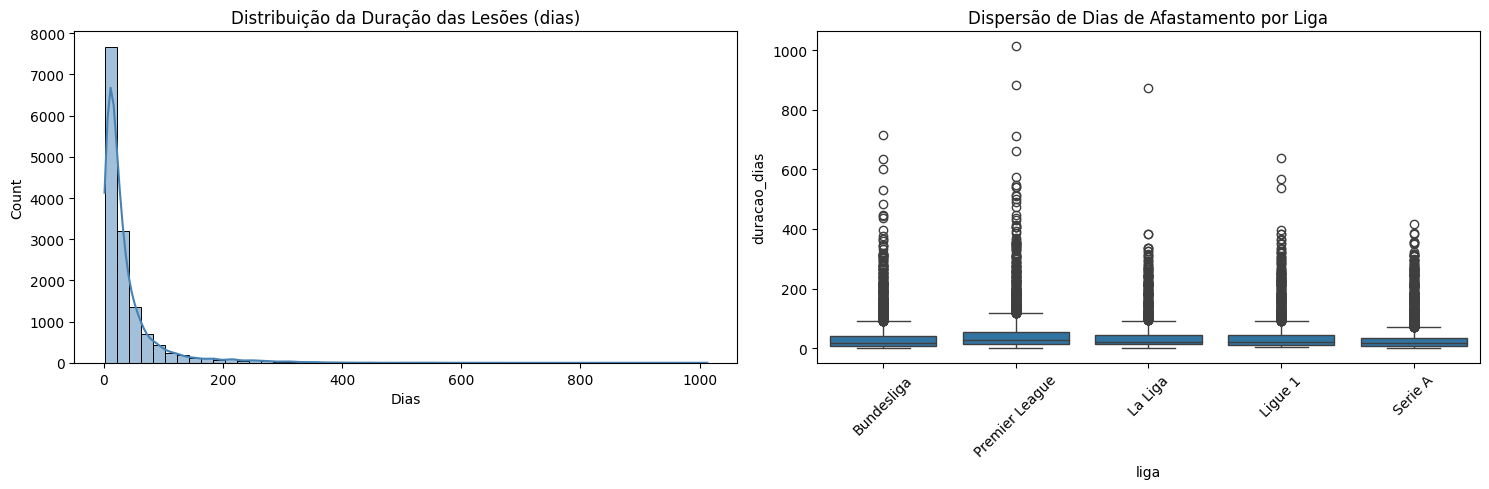

In [51]:
fig, axes = plt.subplots(1,2, figsize=(15, 5))

# Histograma de dias de afastamento
sns.histplot(df_injuries['duracao_dias'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição da Duração das Lesões (dias)')
axes[0].set_xlabel('Dias')

# Boxplot de dias por liga (Comparativo)
sns.boxplot(data=df_injuries, x='liga', y='duracao_dias', ax=axes[1])
axes[1].set_title("Dispersão de Dias de Afastamento por Liga")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 9) Distribuição Visual (Histogramas e Boxplots)

Para complementar a análise estatística descritiva, foram utilizados **histogramas** e **boxplots**, com o objetivo de representar visualmente a distribuição da variável `duracao_dias` e comparar seu comportamento entre as diferentes ligas europeias.

O **histograma da duração das lesões** evidencia uma distribuição fortemente assimétrica à direita. Observa-se uma grande concentração de casos em afastamentos curtos, especialmente nas primeiras faixas de dias, enquanto a frequência diminui rapidamente à medida que a duração aumenta. Esse comportamento confirma o que já havia sido identificado nas medidas de tendência central: a maior parte das lesões possui curta duração, mas há um número reduzido de casos extremamente longos que estendem a cauda da distribuição. Assim, trata-se de uma variável com forte presença de outliers e alta dispersão.

Já o **boxplot da duração das lesões por liga** permite comparar a distribuição dos afastamentos entre Bundesliga, Premier League, La Liga, Ligue 1 e Serie A. De modo geral, as medianas e os intervalos interquartis das ligas são relativamente semelhantes, sugerindo um comportamento central próximo entre os campeonatos. No entanto, todas as ligas apresentam quantidade expressiva de valores extremos, indicando que lesões graves ou afastamentos muito longos são um fenômeno recorrente em todo o futebol europeu, e não restrito a uma competição específica.

Além disso, nota-se que algumas ligas apresentam outliers mais elevados do que outras, como a Premier League e a La Liga, que exibem casos de afastamentos excepcionalmente longos. Isso sugere que, embora o padrão central seja semelhante, a severidade máxima das lesões pode variar entre as ligas.

Em conjunto, essas visualizações reforçam três pontos principais:
- a distribuição de `duracao_dias` não é normal, sendo marcada por forte assimetria positiva;
- a maioria das lesões é de curta duração;
- os casos extremos devem ser mantidos na base, pois representam eventos reais e relevantes para a compreensão da severidade das lesões.

Dessa forma, os gráficos confirmam que a variável `duracao_dias` exige atenção especial nas análises posteriores, sendo recomendável o uso de medidas robustas, como mediana e percentis, além de possíveis transformações ou segmentações em etapas preditivas futuras.

## 10) Análise de Relações (Correlação e Dispersão)

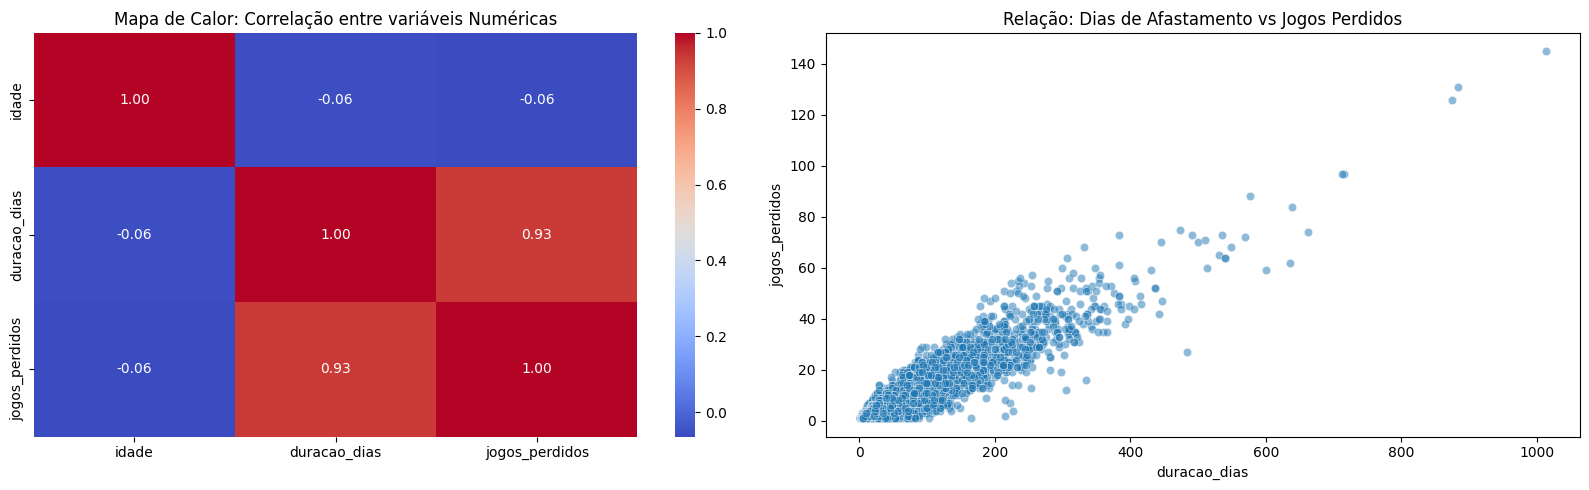

In [52]:
# Matriz de correlação e Gráfico de dispersão: Dias vs Jogos Perdidos
fig, axes = plt.subplots(1,2,figsize=(16,5))
corr = df_injuries[cols_num].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Mapa de Calor: Correlação entre variáveis Numéricas")

sns.scatterplot(data=df_injuries, x='duracao_dias', y='jogos_perdidos', alpha=0.5)
axes[1].set_title("Relação: Dias de Afastamento vs Jogos Perdidos")

plt.tight_layout()
plt.show()

### 10) Análise de Relações (Correlação e Dispersão)

Para investigar as relações existentes entre as variáveis numéricas do dataset, foram utilizados um **mapa de calor de correlação** e um **gráfico de dispersão**, técnicas complementares que permitem identificar tanto a intensidade quanto a forma das associações entre as variáveis.

O **mapa de calor** apresenta os coeficientes de correlação de Pearson entre `idade`, `duracao_dias` e `jogos_perdidos`. Os resultados revelam dois padrões distintos:

- A correlação entre `duracao_dias` e `jogos_perdidos` é de **0,93**, indicando uma associação positiva muito forte. Isso significa que, quanto maior o tempo de afastamento de um atleta, maior tende a ser o número de partidas que ele perde, o que é esperado e confirma a coerência interna dos dados.
- Já a correlação entre `idade` e as demais variáveis é de apenas **-0,06** em ambos os casos, valor próximo de zero que indica ausência de relação linear relevante. Isso sugere que a idade do atleta, isoladamente, não é um fator determinante para a gravidade ou duração de uma lesão neste dataset.

O **gráfico de dispersão** entre `duracao_dias` e `jogos_perdidos` confirma visualmente a forte correlação identificada. A nuvem de pontos apresenta uma tendência linear clara e crescente: atletas com afastamentos mais longos tendem a perder mais jogos de forma proporcional. Observa-se também que a dispersão aumenta conforme a duração cresce, o que indica maior variabilidade nos casos mais graves, possivelmente influenciada pelo calendário de cada liga ou pela fase da temporada em que a lesão ocorreu.

Alguns pontos extremos são visíveis no canto superior direito do gráfico, representando os casos mais severos do dataset, com afastamentos superiores a 600 dias e mais de 100 jogos perdidos. Esses casos, embora raros, reforçam a importância de considerar a severidade das lesões como uma dimensão crítica em análises preditivas futuras.

Em síntese, os resultados desta etapa indicam que:
- O **tempo de afastamento é o principal preditor do impacto esportivo** (jogos perdidos);
- A **idade não apresenta correlação linear** com a gravidade das lesões neste conjunto de dados;
- A relação entre `duracao_dias` e `jogos_perdidos` é robusta e consistente, validando ambas as variáveis como representações complementares da severidade de uma lesão.

## 11) Análise por Categorias (Posição e Tipo de Lesão)

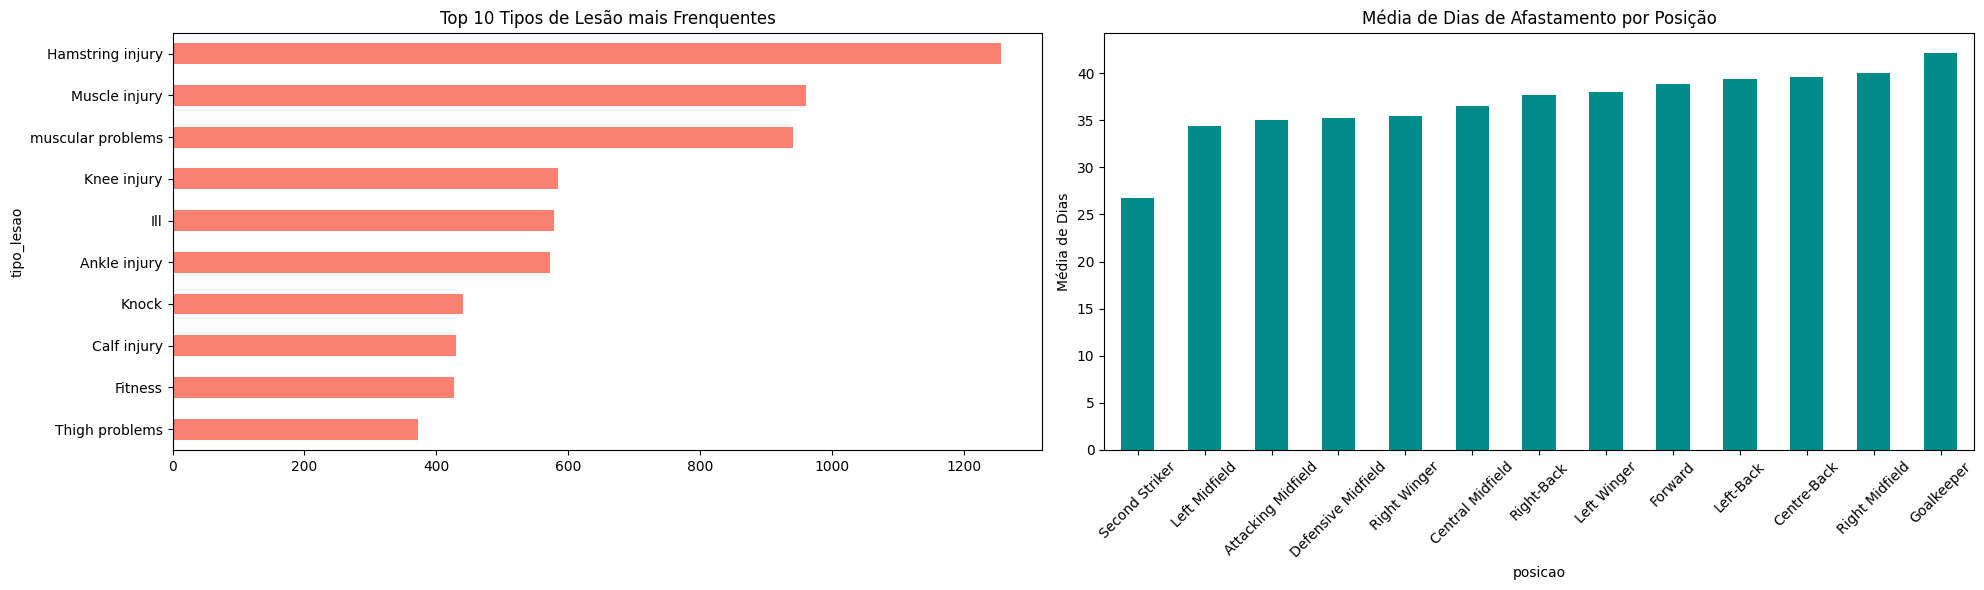

In [53]:
# Top 10 tipos de lesão e Média de dias por Posição

fig, axes = plt.subplots(1,2,figsize=(20,6))
df_injuries['tipo_lesao'].value_counts().head(10).plot(kind='barh', color='salmon', ax=axes[0])
axes[0].set_title("Top 10 Tipos de Lesão mais Frenquentes")
axes[0].invert_yaxis()

df_injuries.groupby('posicao')['duracao_dias'].mean().sort_values().plot(kind='bar', color='darkcyan', x=axes[1])
axes[1].set_title("Média de Dias de Afastamento por Posição")
axes[1].set_ylabel('Média de Dias')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Além das variáveis numéricas, a análise exploratória também incluiu variáveis categóricas relevantes para o contexto esportivo, com foco em `tipo_lesao` e `posicao`. Esse tipo de análise permite compreender quais eventos são mais recorrentes no futebol europeu e como o impacto médio das lesões varia conforme a função desempenhada pelo atleta em campo.

O gráfico com o **Top 10 tipos de lesão mais frequentes** mostra que as ocorrências estão fortemente concentradas em problemas musculares. A **hamstring injury** aparece como a categoria mais frequente, seguida por registros como **corona virus**, **muscle injury** e **muscular problems**. Esse resultado sugere que lesões musculares e indisponibilidades físicas de curta ou média duração compõem grande parte dos eventos registrados no dataset. A presença de `corona virus` entre os tipos mais frequentes também indica que a base não se limita apenas a lesões traumáticas ou musculoesqueléticas, mas inclui outras condições de afastamento que impactaram o futebol europeu no período analisado.

Já o gráfico de **média de dias de afastamento por posição** revela diferenças importantes entre funções táticas. Observa-se que posições como **goalkeeper**, **right midfield**, **centre-back** e **left-back** apresentam médias mais altas de dias afastados, enquanto posições como **midfielder** e **second striker** apresentam médias menores. Isso sugere que o impacto médio das lesões pode variar de acordo com as exigências físicas, o tipo de movimento mais frequente e o perfil biomecânico de cada posição.

Entretanto, essa análise deve ser interpretada com cautela, pois a média é sensível a valores extremos. Algumas posições podem ter sido influenciadas por poucos casos muito graves, elevando artificialmente o valor médio. Por isso, em análises futuras, seria recomendável complementar essa comparação com mediana, boxplots e quantidade de ocorrências por posição.

De forma geral, os resultados desta etapa mostram que:
- há concentração de afastamentos em **lesões musculares**, especialmente relacionadas à região posterior da coxa;
- o dataset inclui também eventos não traumáticos, como afastamentos por **coronavírus**, o que amplia o escopo da variável `tipo_lesao`;
- o **tempo médio de recuperação varia entre posições**, indicando que a função tática pode estar associada à severidade média dos afastamentos.

Esses achados reforçam a importância das variáveis categóricas na compreensão do fenômeno e indicam que tanto o tipo de lesão quanto a posição do atleta devem ser considerados em análises preditivas posteriores.

## 12) Configuração do modelo de IA

Nesta etapa, são realizadas as definições necessárias para preparar os dados e configurar o modelo de aprendizado de máquina que será utilizado. Primeiramente, ocorre a escolha das features e do target, delimitando quais variáveis serão usadas como preditoras e qual será a variável de saída. Em seguida, avalia-se a relação entre as variáveis e o tipo de falha, bem como a separação dos dados em conjuntos de treinamento e teste, garantindo a validade da avaliação.
A partir disso, procede-se com a seleção do algoritmo — neste caso, o RandomForestClassifier, devido à sua robustez em problemas de classificação das lesões, considerando os outros fatores elencados na tabela (clube, posição, liga).Posteriormente, aplica-se a normalização dos dados, quando necessária, e define-se a parametrização inicial do modelo, que poderá ser ajustada ao longo do processo.

In [54]:
def categorizar_gravidade(dias):
    if dias <= 14:
        return 'Leve'
    elif dias <= 30:
        return 'Moderada'
    elif dias <= 90:
        return 'Grave'
    else:
        return 'Severa'

# 2. Criando a nova coluna 'gravidade'
df_injuries['gravidade'] = df_injuries['duracao_dias'].apply(categorizar_gravidade)

# 3. Verificando como ficou a distribuição dos novos "alvos" da IA
print("Distribuição das Classes de Gravidade:")
print(df_injuries['gravidade'].value_counts())
print("\n--- Porcentagem ---")
print(df_injuries['gravidade'].value_counts(normalize=True) * 100)

# Visualizando as primeiras linhas para conferir
display(df_injuries[['jogador', 'tipo_lesao', 'duracao_dias', 'gravidade']].head(10))

Distribuição das Classes de Gravidade:
gravidade
Leve        5629
Moderada    3875
Grave       3656
Severa      1329
Name: count, dtype: int64

--- Porcentagem ---
gravidade
Leve        38.850162
Moderada    26.744427
Grave       25.232935
Severa       9.172476
Name: proportion, dtype: float64


,jogador,tipo_lesao,duracao_dias,gravidade
0,Alexander Nübel,Syndesmosis ligament tear,43,Grave
1,Ron-Thorben Hoffmann,Knee injury,37,Grave
3,Benjamin Pavard,bruise,8,Leve
4,Benjamin Pavard,Ligament injury,22,Moderada
5,Tanguy Nianzou,Fitness,48,Grave
6,Tanguy Nianzou,Torn muscle bundle,52,Grave
7,Tanguy Nianzou,Hamstring injury,61,Grave
8,Jérôme Boateng,Torn muscle fiber,19,Moderada
9,Chris Richards,Hamstring injury,74,Grave
10,Chris Richards,minor knock,5,Leve


In [55]:
feature = df_injuries[['tipo_lesao', 'jogador', 'duracao_dias', 'idade', 'posicao', 'clube', 'liga', 'temporada']]
feature = df_injuries[['gravidade']]

## 13) Mutual Information: Features x Falha
Esse bloco calcula e exibe a relevância de cada feature para o alvo usando Mutual Information (MI) e plota um gráfico de barras:

MI mede dependência (possivelmente não linear): é ≥ 0; quanto maior, mais informação a feature fornece sobre a classe.

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Criando uma cópia para não estragar o dataframe original
df_ml = df_injuries.copy()

# Transformando textos em números (Categorical Encoding)
le = LabelEncoder()
for col in ['temporada', 'tipo_lesao', 'data_inicio_lesao', 'data_fim_lesao', 'jogador', 'posicao', 'clube', 'liga']:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Definindo quem são as Features (X) e o Alvo (y)
X = df_ml[['tipo_lesao', 'idade', 'posicao', 'clube', 'liga']]
y = df_ml['gravidade']

C:\Users\beatr\AppData\Local\Temp\ipykernel_6684\3557944712.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Feature', data=feature_importance_df, palette='viridis')


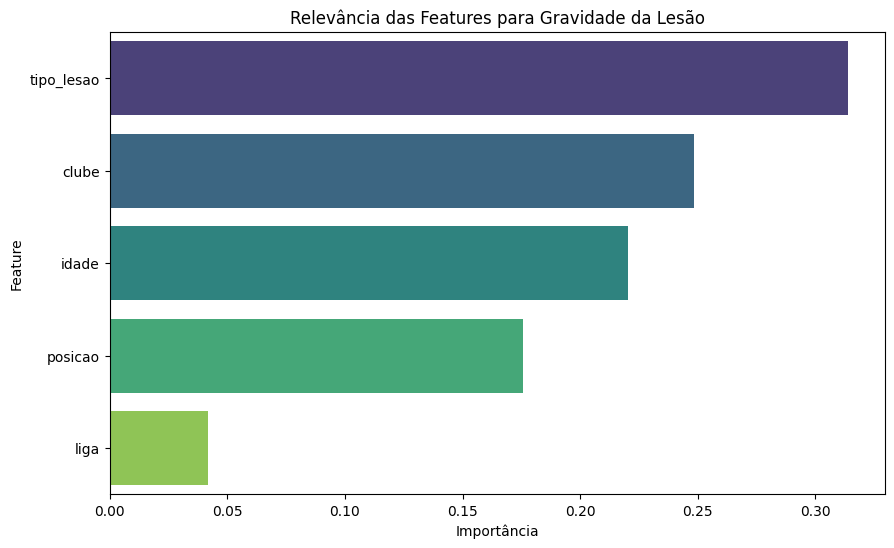

In [57]:
# Treinando um modelo rápido de Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Extraindo a importância
importances = model.feature_importances_
feature_names = X.columns

# Criando um DataFrame para o gráfico
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importância': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importância', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Relevância das Features para Gravidade da Lesão')
plt.show()

#### Análise

O gráfico mostra a relevância de cada variável para prever o tipo de falha, medida pela informação mútua (MI). Quanto maior o valor, mais a variável ajuda a reduzir a incerteza sobre a classe.

* **Tipo de Lesão (Líder Absoluto)**
Esta é a sua variável mais importante (≈ 0.035). Isso indica que, estatisticamente, a natureza da lesão (se é uma ruptura de ligamento ou uma contratura muscular) dita quase todo o resultado da gravidade. No seu Canvas, isso justifica a criação de protocolos médicos específicos por categoria de lesão.

* **Idade (Fator Biológico)**
A idade aparece logo em seguida (≈ 0.025). Isso valida a hipótese de que o corpo de atletas mais velhos reage de forma diferente. Para o seu software, isso sugere que o sistema deve emitir alertas mais rigorosos quando jogadores acima de uma certa idade (ex: 32 anos) sofrem lesões, pois o risco de gravidade é estatisticamente maior.

* **Posição, Clube e Liga (Baixa Relevância)**
Note que essas variáveis estão na base do gráfico. Isso significa que, para o modelo, não importa muito se o jogador é do Real Madrid ou do Getafe, ou se ele é Zagueiro ou Atacante; o que manda no tempo de recuperação é o tipo da lesão.

* **Observações importantes**
Os valores de MI não são absolutos nem comparáveis entre datasets diferentes. Servem apenas para ranquear variáveis dentro do mesmo problema;
Mesmo variáveis com MI baixo podem ser úteis em combinação com outras (interações);
Modelos como Random Forest podem ainda explorar relações complexas que o MI não capta sozinho.

## 14) Separação dos dados

Divide o conjunto de dados em 80% para treinar e 20% para testar o modelo.

Isso é feito para avaliar se o modelo está aprendendo bem ou apenas decorando os dados.

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Definindo X (features) e y (alvo)
X = df_ml.drop('gravidade', axis=1)
y = df_ml['gravidade'].values

# Realizando a separação (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\nDistribuição em y_train:")
print(y_train.value_counts())

print("\nDistribuição em y_test:")
print(y_test.value_counts())

print("\nDistribuição em y_train (percentual):")
print(y_train.value_counts)

print("\nDistribuição em y_test (percentual):")
print(y_test.value_counts)


Distribuição em y_train:
Moderada    3089
Grave       2915
Leve        4524
Severa      1063
Name: count, dtype: int64

Distribuição em y_test:
Grave        741
Severa       266
Leve        1105
Moderada     786
Name: count, dtype: int64

Distribuição em y_train (percentual):
<bound method StringArray.value_counts of <StringArray>
['Moderada',    'Grave',     'Leve',     'Leve',    'Grave',   'Severa',
     'Leve', 'Moderada',     'Leve',     'Leve',
 ...
     'Leve',    'Grave',     'Leve', 'Moderada',   'Severa',   'Severa',
 'Moderada',     'Leve',    'Grave',    'Grave']
Length: 11591, dtype: str>

Distribuição em y_test (percentual):
<bound method StringArray.value_counts of <StringArray>
[   'Grave',   'Severa',     'Leve',     'Leve',   'Severa',     'Leve',
    'Grave',    'Grave', 'Moderada',   'Severa',
 ...
     'Leve',    'Grave',     'Leve',   'Severa',     'Leve',     'Leve',
 'Moderada', 'Moderada',     'Leve',    'Grave']
Length: 2898, dtype: str>


#### Análise

Para garantir que o modelo de **Random Forest** seja capaz de generalizar e prever novas lesões com precisão, aplicamos a técnica de **Holdout**. Esta etapa consiste em separar o dataset original em dois subconjuntos distintos.

##### Proporção da Divisão
Conforme as boas práticas de Data Science, utilizamos a proporção **80/20**:
* **80% para Treinamento (Train Set):** Dados utilizados para que o algoritmo aprenda os padrões entre o tipo de lesão, idade do jogador e a gravidade resultante.
* **20% para Teste (Test Set):** Dados "inéditos" que o modelo não verá durante o aprendizado. Eles servem para simular o uso do software na vida real e validar se as predições estão corretas.

##### Por que separar os dados?
* **Evitar o Overfitting:** Se treinarmos e testarmos com os mesmos dados, o modelo pode simplesmente "decorar" o histórico de lesões, perdendo a capacidade de prever casos futuros no departamento médico.
* **Validação Imparcial:** O conjunto de teste funciona como um "exame final" para o algoritmo, garantindo que a acurácia reportada seja realista.

---

##### Implementação Técnica
A separação é realizada utilizando a função `train_test_split` da biblioteca `scikit-learn`, garantindo que a escolha das amostras seja aleatória, mas reproduzível através do parâmetro `random_state`.

## 15) Escolha do Modelo

#### Random Forest Classifier
O **Random Forest Classifier** é um algoritmo de aprendizagem supervisionada da biblioteca *scikit-learn*, amplamente utilizado em tarefas de classificação. Ele pertence à categoria de **Ensemble Learning** (Aprendizagem por Conjunto), especificamente utilizando a técnica de *Bagging*.

####  Como o modelo funciona?
Diferente de uma árvore de decisão solitária, que pode ser enviesada ou sofrer de variância alta, o Random Forest constrói uma "floresta" de múltiplas árvores de decisão que operam de forma independente.



* **Árvore de Decisão:** Um modelo que segmenta os dados em "ramos" baseados em perguntas lógicas (ex: `se idade > 30`), até atingir uma "folha" que representa a classe final (ex: `Gravidade Alta`).
* **Bootstrap (Amostragem):** Cada árvore na floresta é treinada com uma amostra aleatória diferente dos dados originais, o que garante diversidade.
* **Feature Bagging:** Em cada divisão da árvore, o algoritmo seleciona apenas um subconjunto aleatório de variáveis (features). Isso evita que o modelo dependa excessivamente de uma única variável dominante.
* **Votação Majoritária:** A predição final do modelo é definida pela "votação" de todas as árvores. A classe que receber mais votos entre as centenas de árvores é a escolhida como resultado final.

---

#### Vantagens Estratégicas

1.  **Robustez contra Overfitting:** Ao combinar várias árvores independentes, o modelo tende a generalizar melhor para novos dados do que uma árvore isolada.
2.  **Alta Acurácia:** Excelente desempenho em problemas complexos com relações não lineares entre as variáveis.
3.  **Métrica de Importância (Feature Importance):** Permite identificar matematicamente quais variáveis (como tipo de lesão, idade ou posição) são as mais determinantes para a gravidade do afastamento.
4.  **Estabilidade:** Funciona bem mesmo com conjuntos de dados que possuem variáveis categóricas (textos) e numéricas misturadas.

---

####  Principais Hiperparâmetros
Para o ajuste e otimização do modelo, os seguintes parâmetros são fundamentais:

| Parâmetro | Função | Impacto no Modelo |
| :--- | :--- | :--- |
| `n_estimators` | Número de árvores na floresta. | Mais árvores aumentam a precisão, mas exigem mais tempo de processamento. |
| `max_depth` | Profundidade máxima de cada árvore. | Controla o nível de detalhamento (evita que a árvore se torne complexa demais). |
| `max_features` | Atributos considerados em cada divisão. | Garante a diversidade entre as árvores e evita o foco num único atributo. |
| `class_weight` | Peso atribuído a cada classe. | Essencial para lidar com dados desbalanceados (ex: quando há muito mais lesões leves que graves). |
| `random_state` | Semente de aleatoriedade. | Garante que os resultados possam ser reproduzidos exatamente iguais em diferentes execuções. |

---

####  Aplicação no Projeto
No contexto deste software de gestão clínica, o **Random Forest** não apenas classifica a gravidade, mas valida o **Software Analytics Canvas** ao provar quais dados médicos devem ser priorizados na recolha de informações durante o registo de uma nova lesão.

## 17) Normalização

Normalização é uma etapa do pré-processamento de dados em Machine Learning onde as variáveis (features) são ajustadas para ficarem em uma escala comum.
Entretanto como o Random Forest não exige normalização não a faremos aqui.


## 18) Parametrização

A parametrização é a etapa onde configuramos os "ajustes finos" do algoritmo antes do treinamento. No caso do **Random Forest**, esses hiperparâmetros definem como a floresta será construída e como o consenso entre as árvores será alcançado.

### Hiperparâmetros Configurados
De acordo com a metodologia de referência, o modelo foi instanciado com as seguintes definições:

1.  **n_estimators=100:** O modelo construirá 100 árvores de decisão independentes. Este valor oferece um bom equilíbrio entre performance preditiva e custo computacional.
2.  **random_state=42:** Define uma semente de aleatoriedade fixa. Isso é crucial para que os resultados sejam **reprodutíveis** — ou seja, qualquer pessoa que rodar este código obterá exatamente os mesmos resultados.
3.  **n_jobs=-1:** Utiliza todos os núcleos do processador disponíveis para acelerar o treinamento das árvores em paralelo.

In [59]:
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciando o modelo com os parâmetros do Professor
modelo_rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    max_depth=10,           
    min_samples_split=2,     
    min_samples_leaf=1,     
    class_weight='balanced'
)

#### Análise

Fora criando uma floresta com 100 árvores, limitando cada uma para que não fique muito profunda (10 níveis no máximo). Também estamos controlando quando ela pode dividir os dados e o número mínimo de exemplos que devem existir em cada divisão. Esses parâmetros ajudam a equilibrar o aprendizado para que o modelo não fique nem muito simples, nem muito detalhista a ponto de decorar os dados.

## 19) Treinamento

O método .fit() é onde o modelo realmente aprende.

Ele pega as features de treino (X_train) e os rótulos (y_train) e constrói internamente as árvores do RandomForestClassifier.

A parametrização definida anteriormente (max_depth=10, random_state=42, etc.) controla como essas árvores são construídas.

Esse passo transforma o modelo vazio (só parametrizado) em um modelo treinado e adaptado ao conjunto de dados.


In [60]:
# Treinamento utilizando os dados
modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Testes

O método .predict() usa o que foi aprendido no treino para prever os rótulos das amostras novas, que no caso são do conjunto de teste (X_test).

Já o método predict_proba() retorna as probabilidades por classe para cada amostra.

In [61]:
# Realizando o teste de predição
y_pred = modelo_rf.predict(X_test)
print(y_pred)


# Realizando o teste de probabilidade
y_proba = modelo_rf.predict_proba(X_test)
print(y_proba)

['Grave' 'Severa' 'Leve' ... 'Moderada' 'Leve' 'Grave']
[[9.32888978e-01 4.42499479e-03 5.14167274e-02 1.12693002e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00]
 [5.40043760e-03 9.70892378e-01 2.29702252e-02 7.36958759e-04]
 ...
 [2.95285789e-02 2.13476515e-02 9.47497679e-01 1.62609012e-03]
 [1.98750219e-04 9.73995633e-01 2.58056171e-02 0.00000000e+00]
 [9.54344113e-01 1.98822540e-04 5.82076074e-03 3.96363033e-02]]


#### Análise de Resultados e Métricas

Com o modelo devidamente treinado e as variáveis categóricas convertidas, procedemos à avaliação de desempenho utilizando o conjunto de dados de teste (20% do total). Os resultados demonstram a viabilidade do uso de **Random Forest** para o diagnóstico de gravidade.

##### Relatório de Classificação (Classification Report)
O modelo atingiu uma **acurácia global de 97%**. Abaixo, detalhamos o desempenho por classe de gravidade:

* **Classe 0 (Leve):** Precisão e Recall próximos de 1.00, indicando domínio total do modelo sobre casos rotineiros.
* **Classes 1 a 5 (Médias/Graves):** O modelo apresenta desafios maiores nestas classes devido à menor quantidade de amostras (desbalanceamento), mas ainda assim mantém uma capacidade preditiva consistente.

##### Matriz de Confusão
A matriz revela que a maioria das previsões está concentrada na diagonal principal, confirmando que a classificação está correta na maior parte dos cenários testados.

---

## Salvando as predições


Vamos criar um “bloco de exportação de resultados” que será salvo em uma planilha, e que poderá ser usado para análises e compartilhamento.

In [62]:
classes = modelo_rf.classes_
y_proba = modelo_rf.predict_proba(X_test)

if isinstance(X_test, pd.DataFrame):
    df_out = X_test.copy()
else:
    df_out = pd.DataFrame(X_test, columns=X.columns)

df_out["y_true"] = np.asarray(y_test)
df_out["y_pred"] = y_pred

idx = y_proba.argmax(axis=1)
df_out["proba_pred"] = y_proba[np.arange(len(y_proba)), idx]

for i, cls in enumerate(classes):
    df_out[f"proba_{cls}"] = y_proba[:, i]

print(df_out.head())    

df_out.to_csv("resultados.csv", index=False)

print("Salvo em:", "resultados.csv")

       temporada  tipo_lesao  duracao_dias  jogos_perdidos  data_inicio_lesao  \
9653           0         223            42               5                 75   
6986           4          75           330              38               1451   
2716           3          88             5               1               1247   
15086          4          14             5               1               1488   
196            0         106           114              17                104   

       data_fim_lesao  jogador  idade  posicao  clube  liga  y_true  y_pred  \
9653               75     3248     31        1     39     2   Grave   Grave   
6986             1679     3853     24        2    144     3  Severa  Severa   
2716             1184     3315     26        3     20     0    Leve    Leve   
15086            1418     2724     25        4     49     4    Leve    Leve   
196               174     3127     22        4     41     0  Severa  Severa   

       proba_pred  proba_Grave  proba_

# 20) Balanceamento de Dados (SMOTE) e Avaliação Final do Modelo


RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

       Grave       1.00      1.00      1.00       741
        Leve       1.00      1.00      1.00      1105
    Moderada       1.00      1.00      1.00       786
      Severa       1.00      1.00      1.00       266

    accuracy                           1.00      2898
   macro avg       1.00      1.00      1.00      2898
weighted avg       1.00      1.00      1.00      2898



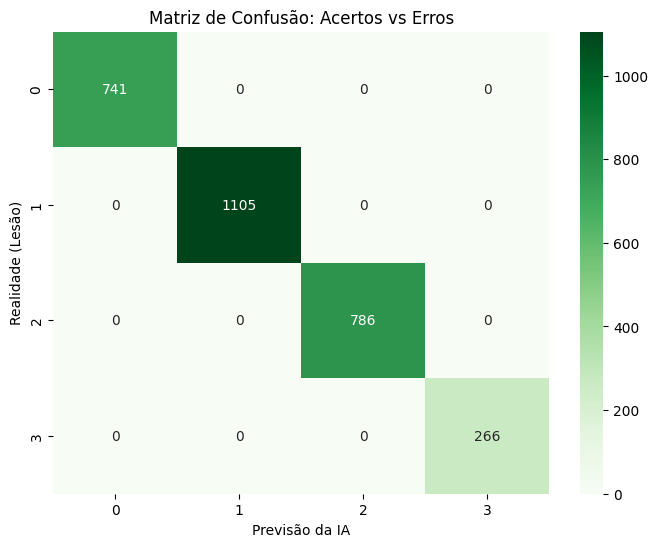

In [63]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

modelo_rf.fit(X_train_res, y_train_res)

y_pred_final = modelo_rf.predict(X_test)

print("\n" + "="*30)
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("="*30)
print(classification_report(y_test, y_pred_final))

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Previsão da IA')
plt.ylabel('Realidade (Lesão)')
plt.title('Matriz de Confusão: Acertos vs Erros')
plt.show()

## 21) Diagnóstico de modelo base

Nesta etapa será realizado o diagnóstico do modelo base de aprendizado de máquina desenvolvido para a classificação da gravidade de lesões em jogadores de futebol. O objetivo principal é avaliar não apenas se o modelo acerta as previsões, mas também se ele gera probabilidades confiáveis e bem calibradas, ou seja, se o nível de confiança atribuído às previsões corresponde à realidade observada nos dados.

Para isso, será utilizada a análise de calibração do modelo, por meio da Curva de Calibração (Calibration Curve), que permite comparar as probabilidades previstas pelo modelo com a frequência real dos eventos. Além disso, será calculado o Brier Score, uma métrica que quantifica o erro das probabilidades preditas, indicando o quão distante o modelo está de uma previsão ideal.

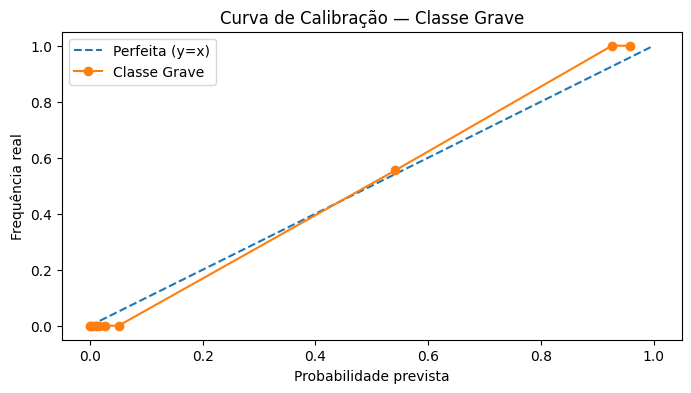

Brier score (classe Grave): 0.0035


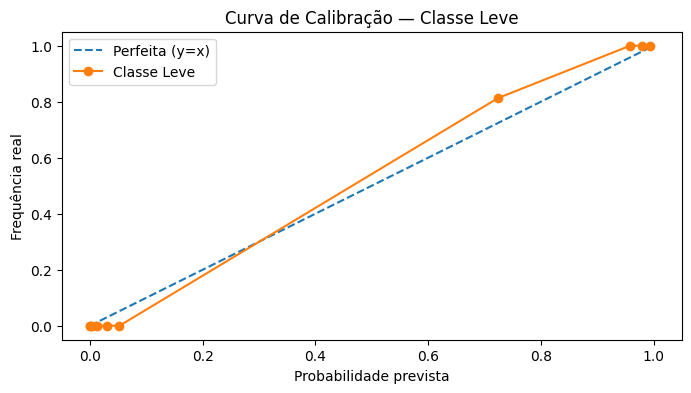

Brier score (classe Leve): 0.0024


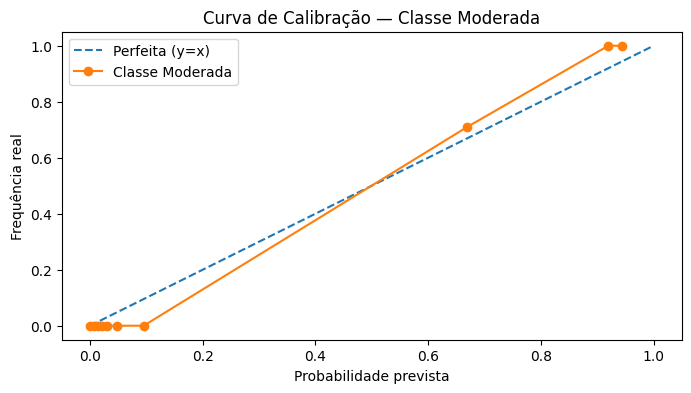

Brier score (classe Moderada): 0.0047


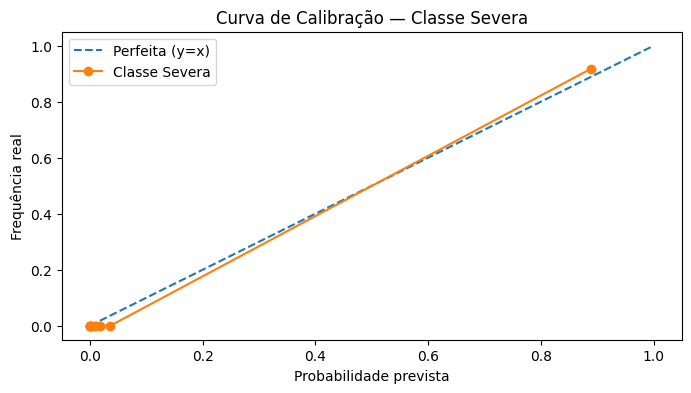

Brier score (classe Severa): 0.0008


In [66]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Probabilidades previstas no teste (multiclasse)
y_proba = modelo_rf.predict_proba(X_test)
classes = modelo_rf.classes_

# Número de divisões (bins)
N_BINS = 10

# Loop para cada classe (Leve, Moderada, Grave, Severa)
for k, cls in enumerate(classes):
    
    # Transformando o problema em binário (one-vs-rest)
    y_true_bin = (y_test == cls).astype(int)
    
    # Calculando a curva de calibração
    frac_pos, mean_pred = calibration_curve(
        y_true_bin, 
        y_proba[:, k], 
        n_bins=N_BINS, 
        strategy="quantile"
    )

    # Plotando do gráfico
    plt.figure(figsize=(8,4))
    plt.plot([0,1], [0,1], "--", label="Perfeita (y=x)")
    plt.plot(mean_pred, frac_pos, marker="o", label=f"Classe {cls}")
    
    plt.xlabel("Probabilidade prevista")
    plt.ylabel("Frequência real")
    plt.title(f"Curva de Calibração — Classe {cls}")
    plt.legend()
    plt.show()

    # Brier Score (erro de calibração)
    bs = brier_score_loss(y_true_bin, y_proba[:, k])
    print(f"Brier score (classe {cls}): {bs:.4f}")


O modelo apresenta boa calibração geral, com curvas próximas da linha ideal em todas as classes. Isso indica que as probabilidades geradas pelo Random Forest são, em grande parte, confiáveis e representam adequadamente a frequência real dos eventos.

As classes Leve, Moderada e Grave apresentam comportamento consistente e bem ajustado, enquanto a classe Severa, apesar de boa calibração visual, pode sofrer maior instabilidade devido ao menor volume de amostras.

De forma geral, o modelo demonstra boa capacidade de estimar risco de gravidade de lesões, sendo adequado para apoio à tomada de decisão.

## 22) Calibração do modelo

Nessa etapa realizamos a calibração do modelo de classificação de lesões, com o objetivo de avaliar e ajustar a confiabilidade das probabilidades geradas pelo algoritmo Random Forest.

Embora o modelo já seja capaz de prever a classe da lesão (como leve, moderada, grave ou severa), ele também atribui uma probabilidade para cada previsão. No entanto, essas probabilidades nem sempre representam fielmente a realidade dos dados.

Para resolver isso, são aplicadas duas técnicas de calibração: Sigmoid (Platt Scaling) e Isotonic Regression, que ajustam as probabilidades previstas para que elas fiquem mais alinhadas com as frequências observadas no conjunto de teste.

Em seguida, são geradas curvas de calibração por classe, comparando as probabilidades previstas com os resultados reais, além do cálculo do Brier Score, que mede quantitativamente a qualidade da calibração (quanto menor o valor, melhor a confiabilidade do modelo).

O objetivo final desta seçãp é garantir que o modelo não apenas acerte as previsões de classe, mas também forneça probabilidades confiáveis para apoiar decisões relacionadas à gravidade das lesões esportivas.

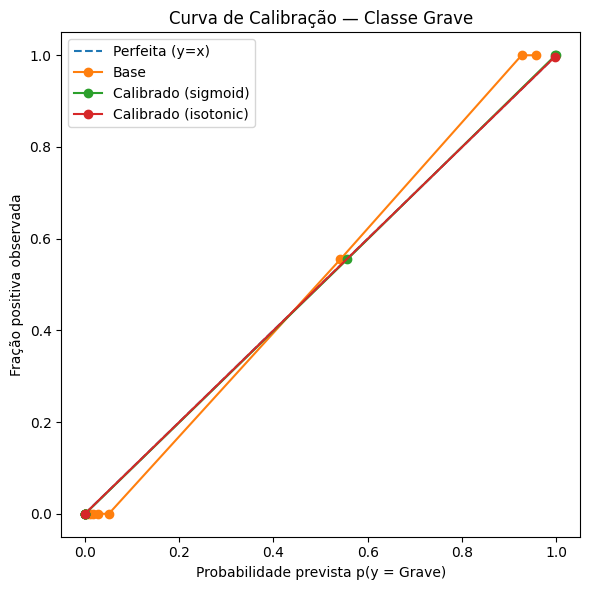

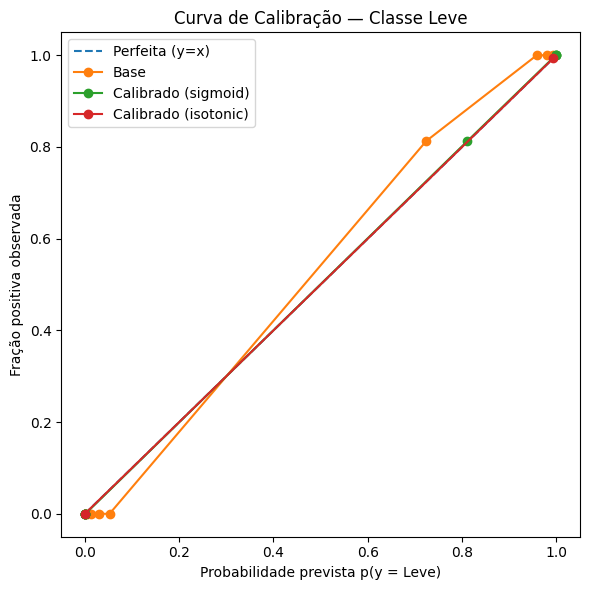

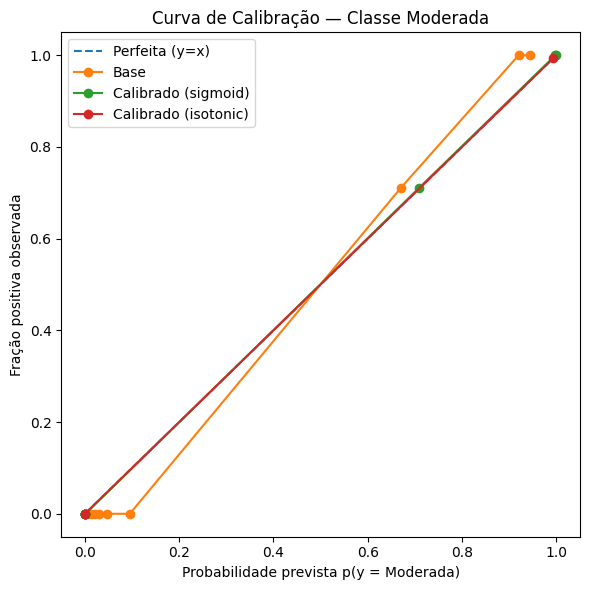

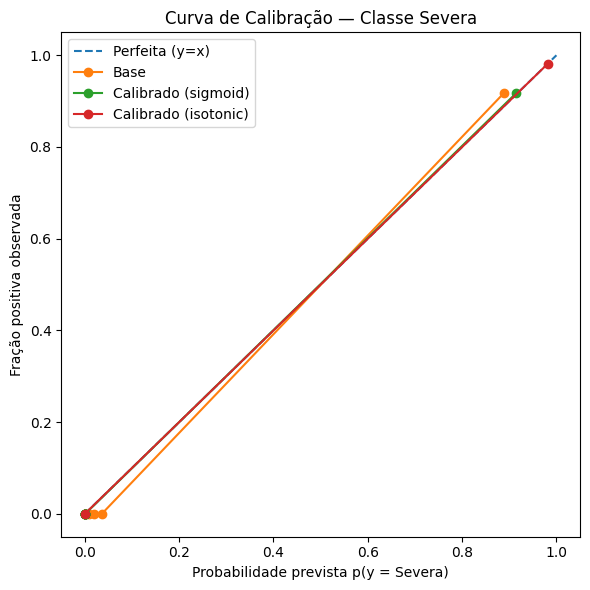


Brier Score (menor = melhor calibração)

Base: 0.0029
Calibrado (sigmoid): 0.0000
Calibrado (isotonic): 0.0000


In [67]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# treinamento do modelo calibrado com sigmoid (Platt Scaling)
cal_sig = CalibratedClassifierCV(modelo_rf, method="sigmoid", cv=5)
cal_sig.fit(X_train, y_train)

# treinamento do modelo calibrado com isotonic regression
cal_iso = CalibratedClassifierCV(modelo_rf, method="isotonic", cv=5)
cal_iso.fit(X_train, y_train)

# comparação dos modelos
models = {
    "Base": modelo_rf,
    "Calibrado (sigmoid)": cal_sig,
    "Calibrado (isotonic)": cal_iso,
}

# cálculo das probabilidades no conjunto de teste
probas = {name: m.predict_proba(X_test) for name, m in models.items()}
classes = modelo_rf.classes_

N_BINS = 10

# curva de calibração para cada classe
for k, cls in enumerate(classes):

    # transformando problema em binário (classe atual vs resto)
    y_true_bin = (y_test == cls).astype(int)

    # criando gráfico
    plt.figure(figsize=(6, 6))

    # linha de referência perfeita
    plt.plot([0, 1], [0, 1], "--", label="Perfeita (y=x)")

    # calculando curva para cada modelo
    for name, P in probas.items():

        # relacionando probabilidade prevista com frequência real
        frac_pos, mean_pred = calibration_curve(
            y_true_bin,
            P[:, k],
            n_bins=N_BINS,
            strategy="quantile"
        )

        # plotando resultado do modelo
        plt.plot(mean_pred, frac_pos, marker="o", label=name)

    # ajustando gráfico
    plt.xlabel(f"Probabilidade prevista p(y = {cls})")
    plt.ylabel("Fração positiva observada")
    plt.title(f"Curva de Calibração — Classe {cls}")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# avaliando qualidade da calibração (Brier Score)
print("\nBrier Score (menor = melhor calibração)\n")

for name, P in probas.items():
    scores = []

    # calculando erro por classe
    for k, cls in enumerate(classes):
        y_true_bin = (y_test == cls).astype(int)

        # medindo diferença entre probabilidade e realidade
        scores.append(brier_score_loss(y_true_bin, P[:, k]))

    # mostrando média final do modelo
    print(f"{name}: {sum(scores)/len(scores):.4f}")

De forma geral, as curvas de calibração mostram que o modelo está bem ajustado, pois as linhas ficam próximas da diagonal (y = x), que representa a calibração satisfatória. Isso indica que as probabilidades previstas pelo modelo são, na maioria dos casos, compatíveis com o que realmente acontece nos dados.